# Introduction

# Liturature

# Data

In [2]:
import pandas as pd

df = pd.read_csv("../../Data/Monday_Combined_dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

In [3]:
print(df.head())
print(df.tail())
print(df.columns)
print(df.shape)

        date  gas_price  wti_price  national_gas_price
0 2021-04-19      2.491      63.33               2.855
1 2021-04-26      2.475      62.02               2.872
2 2021-05-03      2.481      64.46               2.890
3 2021-05-10      2.563      64.92               2.961
4 2021-05-17      2.693      66.24               3.028
          date  gas_price  wti_price  national_gas_price
257 2026-03-23      3.659      89.33               3.961
258 2026-03-30      3.529     104.69               3.990
259 2026-04-06      3.807     114.01               4.120
260 2026-04-13      3.880     100.72               4.123
261 2026-04-20      3.639      91.06               4.044
Index(['date', 'gas_price', 'wti_price', 'national_gas_price'], dtype='str')
(262, 4)


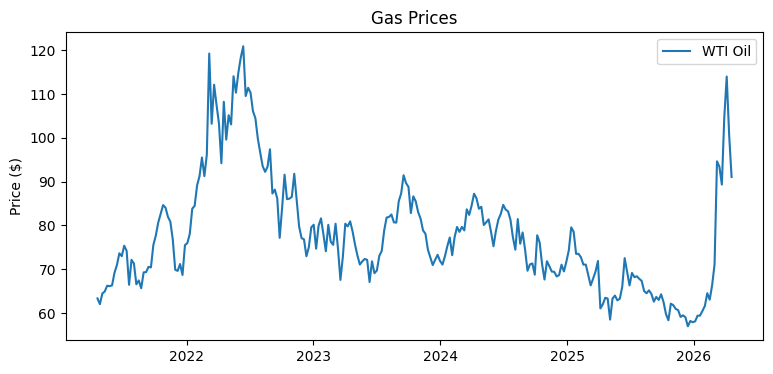

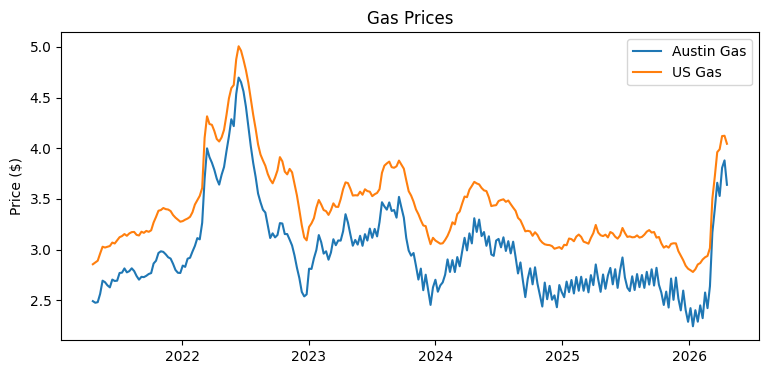

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9,4))

plt.plot(df["date"], df["wti_price"], label="WTI Oil")

plt.legend()
plt.title("Gas Prices")
plt.ylabel("Price ($)")
plt.show()

plt.figure(figsize=(9,4))

plt.plot(df["date"], df["gas_price"], label="Austin Gas")
plt.plot(df["date"], df["national_gas_price"], label="US Gas")

plt.legend()
plt.title("Gas Prices")
plt.ylabel("Price ($)")
plt.show()

Austin gas prices appear more volatile than the national average, which makes sense. The US series is an average across many locations, so it smooths out local shocks and short-term fluctuations. In contrast, Austin reflects a single market, so local supply or demand changes show up more directly. Because of this, the Austin series naturally shows more variation over time compared to the smoother national benchmark.

(see data/qualityCheck.ipynb for more)

# Preliminary tests

### Non-stationarity at i(0)

In [6]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name, reg_type="c"):
    result = adfuller(series.dropna(), regression=reg_type)
    print(name)
    print("ADF Stat:", round(result[0], 5))
    print("p-value:", round(result[1], 5))
    print("-"*30) #prints dashed lines/readability

# Random walk (with constant/ mean != zero)) v.s. Stationarity
adf_test(df["gas_price"], "Austin Gas (RW v.s. Stat)", "c")
adf_test(df["wti_price"], "WTI (RW v.s. Stat)", "c")
adf_test(df["national_gas_price"], "National Gas (RW v.s. Stat)", "c")

# Random walk with drift v.s. Determinstic trend (Trend Stationary) w/ constant
adf_test(df["gas_price"], "Austin Gas (drift v.s. trend)", "ct")
adf_test(df["wti_price"], "WTI (drift v.s. trend)", "ct")
adf_test(df["national_gas_price"], "National Gas (drift v.s. trend)", "ct")

Austin Gas (RW v.s. Stat)
ADF Stat: -2.644
p-value: 0.08424
------------------------------
WTI (RW v.s. Stat)
ADF Stat: -2.5921
p-value: 0.09464
------------------------------
National Gas (RW v.s. Stat)
ADF Stat: -2.7556
p-value: 0.0649
------------------------------
Austin Gas (drift v.s. trend)
ADF Stat: -3.08263
p-value: 0.11042
------------------------------
WTI (drift v.s. trend)
ADF Stat: -2.94178
p-value: 0.14909
------------------------------
National Gas (drift v.s. trend)
ADF Stat: -2.96721
p-value: 0.14148
------------------------------


I ran the ADF test with a constant to allow for stationarity around a non-zero mean, which is appropriate for price data. I fail to reject the null of a unit root for all series, suggesting they behave like random walks at I(0). I also include a trend specification as a robustness check, and the results remain consistent.

To co-integrated we need the sereis to be stationary at I(1), after the first difference (becasue we have random walk and no trend).

First difference:
$$
y_t = \alpha + y_{t-1} + \varepsilon_t
$$

$$
LHS: \Delta y_t = y_t - y_{t-1}
$$
$$
RHS: \alpha + \varepsilon_t = (\alpha + y_{t-1} + \varepsilon_t) - y_{t-1}
$$

$$
\Delta y_t = \alpha + \varepsilon_t
$$

### Stationarity at i(1)

In [7]:
df["d_gas"] = df["gas_price"].diff()
df["d_wti"] = df["wti_price"].diff()
df["d_nat"] = df["national_gas_price"].diff()

adf_test(df["d_gas"], "Δ Austin Gas", "c")
adf_test(df["d_wti"], "Δ WTI", "c")
adf_test(df["d_nat"], "Δ National Gas", "c")

Δ Austin Gas
ADF Stat: -9.23496
p-value: 0.0
------------------------------
Δ WTI
ADF Stat: -6.89718
p-value: 0.0
------------------------------
Δ National Gas
ADF Stat: -8.59496
p-value: 0.0
------------------------------


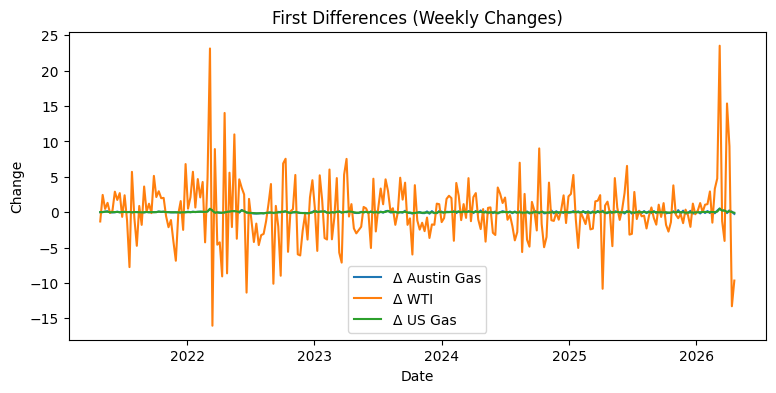

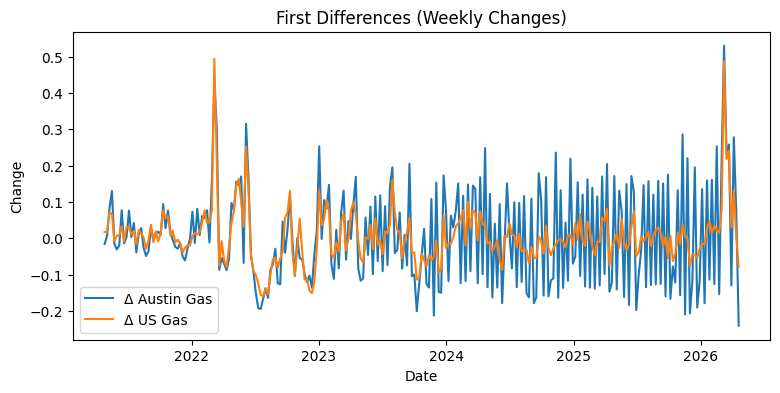

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,4))

plt.plot(df["date"], df["d_gas"], label="Δ Austin Gas")
plt.plot(df["date"], df["d_wti"], label="Δ WTI")
plt.plot(df["date"], df["d_nat"], label="Δ US Gas")

plt.legend()
plt.title("First Differences (Weekly Changes)")
plt.xlabel("Date")
plt.ylabel("Change")
plt.show()

plt.figure(figsize=(9,4))

plt.plot(df["date"], df["d_gas"], label="Δ Austin Gas")
plt.plot(df["date"], df["d_nat"], label="Δ US Gas")

plt.legend()
plt.title("First Differences (Weekly Changes)")
plt.xlabel("Date")
plt.ylabel("Change")
plt.show()

We have confirmed that all series are non-stationary in levels but become stationary after first differencing, indicating they are likely I(1). This allows us to proceed with testing for a long-run equilibrium relationship between gasoline prices and oil prices using a cointegration framework.

The next step is to estimate the long-run relationship (e.g., via Engle-Granger) and obtain the residuals, which will serve as the error correction term. If the residuals are stationary, this confirms cointegration and justifies estimating an Error Correction Model (ECM) to capture both long-run equilibrium behavior and short-run dynamics.

### Addressing Volitilty and Pricing Cycle

### Next Steps: From Stationarity to ECM

We have established that all series are I(1), meaning they are non-stationary in levels but stationary in first differences. This allows us to proceed with testing for a long-run equilibrium relationship between gasoline prices and oil prices.

The next step is to estimate the long-run relationship using an Engle-Granger approach:

* Estimate the long-run equation (levels):
Regress gasoline prices on oil prices to obtain the equilibrium relationship.

* Test residuals for stationarity:
If the residuals are stationary, this confirms cointegration.

* Construct the Error Correction Model (ECM):
Use the lagged residuals as the error correction term to model short-run dynamics.

* Account for structural changes:
Given the increase in volatility after 2024, allow for changes in short-run dynamics by:
    * Splitting the sample (pre/post-2024), or
    * Including interaction terms or a post-2024 dummy

This framework allows us to separate long-run equilibrium behavior from short-run adjustments while accounting for changes in pricing dynamics.

# The Long-run relationship & Co-Integration 

## Austin Gasoline and TWI oil

### Long-Run Relationship (Engle-Granger Step 1)

As mentioned, the first step in testing for cointegration in the Engle-Granger framework is to estimate the long-run relationship via OLS.

We estimate:

$$
gas_t = \alpha + \beta \cdot WTI_t + u_t
$$

where:

- \( gas_t \) is the retail gasoline price (Austin)  
- \( WTI_t \) is the crude oil price  
- \( u_t \) is the long-run equilibrium error  

If \( gas_t \) and \( WTI_t \) are cointegrated, the residuals \( u_t \) should be stationary.

This will be tested in the next step.

In [9]:
import statsmodels.api as sm

# make sure no missing values
ecm_df = df[["gas_price", "wti_price"]].dropna()

# dependent and independent variables
y = ecm_df["gas_price"]
X = sm.add_constant(ecm_df["wti_price"])

# estimate long-run model
long_run_model = sm.OLS(y, X).fit()

# print results
print(long_run_model.summary())

                            OLS Regression Results                            
Dep. Variable:              gas_price   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     942.3
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           1.95e-88
Time:                        20:28:40   Log-Likelihood:                 40.365
No. Observations:                 262   AIC:                            -76.73
Df Residuals:                     260   BIC:                            -69.59
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6367      0.077      8.247      0.0

A $1 increase in WTI → approx. 3 cent increase in gas prices (long-run)

### Cointegration Test (Engle-Granger Step 2)

We test whether the residuals from the long-run relationship are stationary using the Augmented Dickey-Fuller (ADF) test.

If the residuals are stationary, this confirms that gasoline and oil prices are cointegrated, meaning they share a stable long-run equilibrium relationship.

In [10]:
from statsmodels.tsa.stattools import adfuller

# extract residuals
ecm_df["residuals"] = long_run_model.resid

# ADF test on residuals (NO constant)
adf_result = adfuller(ecm_df["residuals"], regression="n")

print("ADF Stat:", adf_result[0])
print("p-value:", adf_result[1])

ADF Stat: -3.7654693571710105
p-value: 0.00018141201326741624


As seen above: the residuals are stationary (highly significant) 
    
-> There likely exists a stable long-run equilibrium relationship between Austin gasoline and WTI oil prices.

## U.S. Gasoline and TWI oil

### Engle-Grager Steps 1 & 2

Engle–Granger Steps (U.S. Gasoline & WTI)

We repeat the Engle–Granger two-step procedure for U.S. gasoline prices and WTI oil prices.

**Step 1:** Estimate the long-run relationship in levels:

$$
gas^{US}_t = \alpha + \beta \cdot WTI_t + u_t
$$

$$
gas_t^{US} = 1.1635 + 0.0290 \cdot WTI_t + u_t
$$

In [17]:
# make sure no missing values
ecm_df = df[["national_gas_price", "wti_price"]].dropna()

# dependent and independent variables
y = ecm_df["national_gas_price"]
X = sm.add_constant(ecm_df["wti_price"])

# estimate long-run model
long_run_model = sm.OLS(y, X).fit()

# print results
print(long_run_model.summary())

                            OLS Regression Results                            
Dep. Variable:     national_gas_price   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     1076.
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           2.08e-94
Time:                        20:58:55   Log-Likelihood:                 67.291
No. Observations:                 262   AIC:                            -130.6
Df Residuals:                     260   BIC:                            -123.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1635      0.070     16.702      0.0

**Step 2:** Test the residuals \(u_t\) for stationarity using the ADF test.

If the residuals are stationary, this indicates that U.S. gasoline and oil prices are cointegrated and share a stable long-run relationship.

$$
u_{t-1} = gas_{t-1}^{US} - 1.1635 - 0.0290 \cdot WTI_{t-1}
$$

In [11]:
# Step 1: Long-run regression
us_df = df[["national_gas_price", "wti_price"]].dropna()

y = us_df["national_gas_price"]
X = sm.add_constant(us_df["wti_price"])

us_lr_model = sm.OLS(y, X).fit()

# Step 2: ADF test on residuals
from statsmodels.tsa.stattools import adfuller

us_resid = us_lr_model.resid
adf_result = adfuller(us_resid, regression="n")

print("ADF Stat:", adf_result[0])
print("p-value:", adf_result[1])

ADF Stat: -4.273575615009863
p-value: 2.433299395059033e-05


# Error-Correction Model (ECM)

## Math Proof ECM (1,1)

We begin with the ADL(1,1) specification:

\begin{equation}
gas_t = \alpha_0 + \alpha_1 gas_{t-1} + \beta_0 WTI_t + \beta_1 WTI_{t-1} + \varepsilon_t
\tag{1}
\end{equation}

Subtract $ gas_{t-1} $ from both sides:

\begin{equation}
gas_t - gas_{t-1} = \alpha_0 + \alpha_1 gas_{t-1} - gas_{t-1} + \beta_0 WTI_t + \beta_1 WTI_{t-1} + \varepsilon_t
\tag{2}
\end{equation}

Rearrange terms:

\begin{equation}
\Delta gas_t = \alpha_0 + (\alpha_1 - 1) gas_{t-1} + \beta_0 WTI_t + \beta_1 WTI_{t-1} + \varepsilon_t
\tag{3}
\end{equation}

Now add and subtract $ \beta_0 WTI_{t-1} $:

\begin{equation}
\Delta gas_t = \alpha_0 + (\alpha_1 - 1) gas_{t-1} + \beta_0 (WTI_t - WTI_{t-1}) + (\beta_0 + \beta_1) WTI_{t-1} + \varepsilon_t
\tag{4}
\end{equation}

Use difference notation:

\begin{equation}
\Delta gas_t = \alpha_0 + (\alpha_1 - 1) gas_{t-1} + \beta_0 \Delta WTI_t + (\beta_0 + \beta_1) WTI_{t-1} + \varepsilon_t
\tag{5}
\end{equation}

Now group the lagged level terms:

\begin{equation}
\Delta gas_t = \alpha_0 + \beta_0 \Delta WTI_t -(1 - \alpha_1)\left( gas_{t-1} - \frac{\beta_0 + \beta_1}{1 - \alpha_1} WTI_{t-1} \right) + \varepsilon_t
\tag{6}
\end{equation}

Define the long-run equilibrium coefficient:

\begin{equation}
\lambda_1 = \frac{\beta_0 + \beta_1}{1 - \alpha_1}
\tag{7}
\end{equation}

Then define the error-correction term:

\begin{equation}
u_{t-1} = gas_{t-1} - \lambda_1 WTI_{t-1}
\tag{8}
\end{equation}

Substitute into (6):

\begin{equation}
\Delta gas_t = \alpha_0 + \beta_0 \Delta WTI_t - (1 - \alpha_1) u_{t-1} + \varepsilon_t
\tag{9}
\end{equation}

Let:

\begin{equation}
\gamma = -(1 - \alpha_1)
\tag{10}
\end{equation}

Final ECM form:

\begin{equation}
\Delta gas_t = c + \beta_0 \Delta WTI_t + \gamma u_{t-1} + \varepsilon_t
\tag{11}
\end{equation}

#### Variable Definitions

### Variable Definitions

**Core ECM Components:**

- $\beta_0$: short-run pass-through coefficient (immediate effect of oil price changes on gasoline prices)  
- $\gamma = -(1 - \alpha_1)$: speed of adjustment back to equilibrium  
- $u_{t-1} = gas_{t-1} - \lambda_1 WTI_{t-1}$: lagged deviation from long-run equilibrium (error-correction term)  

**Long-Run Relationship:**

- $\lambda_1 = \frac{\beta_0 + \beta_1}{1 - \alpha_1}$: long-run pass-through coefficient  

**ADL(1,1) Structural Parameters:**

- $\beta_1$: lagged oil price effect (delayed pass-through)  
- $\alpha_1$: persistence in gasoline prices  

**Transformed Variables:**

- $\Delta gas_t = gas_t - gas_{t-1}$: change in gasoline prices  
- $\Delta WTI_t = WTI_t - WTI_{t-1}$: change in oil prices  

**Original Level Variables:**

- $gas_t$: retail gasoline price (Austin)  
- $WTI_t$: crude oil price  

**Error Term:**

- $\varepsilon_t$: short-run shock

## ECM Model (Emperical Specification)

From equation (11), gasoline price changes are driven by two components:

- **Short-run oil price changes:** $ \Delta WTI_t $  
  This captures immediate movements in crude oil prices. The coefficient $ \beta_1 $ measures the **short-run pass-through**, i.e., how much gasoline prices change in response to a one-unit change in oil prices within the same period.

- **Long-run disequilibrium (error correction term):** $ u_{t-1} $  
  This represents the deviation of gasoline prices from their long-run equilibrium with oil prices in the previous period:
  $$
  u_{t-1} = gas_{t-1} - \lambda_1 WTI_{t-1}
  $$
  $$
  \lambda_1 = \frac{\beta_0 + \beta_1}{1 - \alpha_1} 

**Interpretation of $\gamma$:**

- If $\gamma < 0$, gasoline prices correct deviations from the long-run equilibrium over time  
- The magnitude of $\gamma$ determines how quickly this adjustment occurs  
- For example, $\gamma = -0.2$ implies that approximately 20% of the deviation from equilibrium is corrected each week  

Together, $\beta_0$ and $\gamma$ separate:

- **Short-run dynamics** (immediate response to oil price changes)  
- **Long-run adjustment** (correction toward equilibrium)

## ECM Model (Austin)

#### ECM variable Creation

In [12]:
df = pd.read_csv("../../Data/Monday_Combined_dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

In [15]:
# Long-run model (on Monday data)
y_lr = df["gas_price"]
X_lr = sm.add_constant(df["wti_price"])

long_run_model = sm.OLS(y_lr, X_lr).fit()

# Create ECM dataframe
ecm_df = df.copy()

# residuals
ecm_df["u_t"] = long_run_model.resid

# first differences
ecm_df["d_gas"] = ecm_df["gas_price"].diff()
ecm_df["d_wti"] = ecm_df["wti_price"].diff()

# ADL(1,1) ECM terms
ecm_df["d_gas_lag1"] = ecm_df["d_gas"].shift(1)
ecm_df["d_wti_lag1"] = ecm_df["d_wti"].shift(1)
ecm_df["d_gas_lag2"] = ecm_df["d_gas"].shift(2)
ecm_df["d_wti_lag2"] = ecm_df["d_wti"].shift(2)
ecm_df["u_lag"] = ecm_df["u_t"].shift(1)

# drop NA
ecm_adl22_df = ecm_df.dropna().copy()

In [16]:
y = ecm_adl22_df["d_gas"]

X = ecm_adl22_df[
    ["d_gas_lag1", "d_gas_lag2", "d_wti", "d_wti_lag1", "d_wti_lag2", "u_lag"]
]

X = sm.add_constant(X)

ecm_model = sm.OLS(y, X).fit()
print(ecm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_gas   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     38.87
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           2.68e-33
Time:                        20:30:53   Log-Likelihood:                 238.78
No. Observations:                 259   AIC:                            -463.6
Df Residuals:                     252   BIC:                            -438.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.006      0.103      0.9

#### ECM regression

#### Estimated ECM Specification



The Error Correction Model can be written as:

$$
\Delta gas_t = \alpha + \beta_0 \Delta WTI_t + \beta_1 \Delta WTI_{t-1} + \beta_2 \Delta WTI_{t-2}
+ \alpha_1 \Delta gas_{t-1} + \alpha_2 \Delta gas_{t-2} + \gamma u_{t-1} + \varepsilon_t
$$

where the error correction term is defined as:

$$
u_{t-1} = gas_{t-1} - \alpha - \beta \cdot WTI_{t-1}
$$

Using the estimated coefficients, the Error Correction Model can be written as:

$$
\Delta gas_t =
0.0006
- 0.3541 \Delta gas_{t-1}
+ 0.1617 \Delta gas_{t-2}
+ 0.0093 \Delta WTI_t
+ 0.0151 \Delta WTI_{t-1}
+ 0.0084 \Delta WTI_{t-2}
- 0.1168 u_{t-1}
+ \varepsilon_t
$$

Substituting the long-run equilibrium error:

$$
u_{t-1} = gas_{t-1} - 0.6367 - 0.0301 \cdot WTI_{t-1}
$$

The full model becomes:

$$
\Delta gas_t =
0.0006
- 0.3541 \Delta gas_{t-1}
+ 0.1617 \Delta gas_{t-2}
+ 0.0093 \Delta WTI_t
+ 0.0151 \Delta WTI_{t-1}
+ 0.0084 \Delta WTI_{t-2}
- 0.1168 (gas_{t-1} - 0.6367 - 0.0301 *WTI_{t-1})
+ \varepsilon_t
$$

#### ECM Model Results

The estimated ECM (2,2) yields the following key results:

- Immediate oil effect: β₀ ≈ 0.0093 (p < 0.001)  
- Lagged oil effects: β₁ ≈ 0.0151, β₂ ≈ 0.0084 (p < 0.001)  
- Lagged gasoline effects: α₁ ≈ −0.3541, α₂ ≈ 0.1617 (p < 0.01)  
- Error correction coefficient: γ ≈ −0.1168 (p < 0.01)  

The positive and significant oil price coefficients indicate that a $1 increase in oil prices raises Austin gasoline prices by about 0.93 cents in the same week, an additional 1.51 cents in the following week, and 0.84 cents in the second lag. This implies a total short-run pass-through of approximately **3.28 cents** over three weeks.

The negative and significant error correction coefficient implies that approximately **11.7%** of any deviation from the long-run equilibrium is corrected each week.

Overall, Austin gasoline prices exhibit a stronger cumulative response to oil price changes and adjust gradually back toward the long-run equilibrium.

## ECM Model (National)

#### ECM Model (Variable Creation, ECM Regression, Results)

We estimate the Error Correction Model for U.S. gasoline prices using an ECM (1,1) specification:

$$
\Delta gas_t^{US} = \alpha + \beta_0 \Delta WTI_t + \beta_1 \Delta WTI_{t-1} + \alpha_1 \Delta gas_{t-1} + \gamma u_{t-1} + \varepsilon_t
$$

where \(u_{t-1}\) is the lagged residual from the long-run relationship.

A significant negative \(\gamma\) indicates that U.S. gasoline prices adjust back toward the long-run equilibrium with oil prices over time, while the lagged difference terms capture short-run dynamics and persistence in price changes.

In [ ]:
# Residuals from long-run model
us_df["u_t"] = us_lr_model.resid

# First differences
us_df["d_gas"] = us_df["national_gas_price"].diff()
us_df["d_wti"] = us_df["wti_price"].diff()

# Lagged differences (THIS is what makes it (1,1))
us_df["d_gas_lag1"] = us_df["d_gas"].shift(1)
us_df["d_wti_lag1"] = us_df["d_wti"].shift(1)

# Lagged error correction term
us_df["u_lag"] = us_df["u_t"].shift(1)

# Drop missing values
us_ecm_df = us_df.dropna().copy()

# ECM (1,1) regression
y = us_ecm_df["d_gas"]

X = us_ecm_df[[
    "d_wti",        # current ΔWTI
    "d_wti_lag1",   # lagged ΔWTI
    "d_gas_lag1",   # lagged Δgas
    "u_lag"         # error correction term
]]

X = sm.add_constant(X)

us_ecm_model = sm.OLS(y, X).fit()

print(us_ecm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_gas   R-squared:                       0.611
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     100.2
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           3.90e-51
Time:                        00:30:29   Log-Likelihood:                 423.00
No. Observations:                 260   AIC:                            -836.0
Df Residuals:                     255   BIC:                            -818.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.003      0.319      0.7

### Estimated ECM (1,1) – U.S.

$$
\Delta gas_t =
0.0010
+ 0.0075 \Delta WTI_t
+ 0.0057 \Delta WTI_{t-1}
+ 0.3846 \Delta gas_{t-1}
- 0.0738 u_{t-1}
+ \varepsilon_t
$$

Substituting the long-run equilibrium error:

$$
u_{t-1} = gas_{t-1}^{US} - 1.1635 - 0.0290 \cdot WTI_{t-1}
$$

$$
\Delta gas_t =
0.0010
+ 0.0075 \Delta WTI_t
+ 0.0057 \Delta WTI_{t-1}
+ 0.3846 \Delta gas_{t-1}
- 0.0738 gas_{t-1}^{US} - 1.1635 - 0.0290 \cdot WTI_{t-1}
+ \varepsilon_t
$$

The estimated ECM (1,1) yields:

• Immediate oil effect: β₀ ≈ 0.0075 (p < 0.001)  
• Lagged oil effect: β₁ ≈ 0.0057 (p < 0.001)  
• Lagged gasoline change: α₁ ≈ 0.3846 (p < 0.001)  
• Error correction coefficient: γ ≈ −0.0738 (p < 0.001)  

The positive and significant oil price coefficients indicate that a $1 increase in oil prices raises gasoline prices by about 0.75 cents in the same week and an additional 0.57 cents in the following week. This implies a total short-run pass-through of approximately 1.32 cents.

The positive and significant lagged gasoline term suggests persistence in gasoline price changes, meaning that increases tend to partially carry over into the next period.

The negative and significant error correction coefficient implies that approximately 7.4% of any deviation from the long-run equilibrium is corrected each week.

Overall, U.S. gasoline prices exhibit gradual adjustment toward equilibrium, with oil price shocks affecting gasoline prices both immediately and with a short delay.

# Results

### Comparison of Coeff. for Austin vs U.S. ECMs

$$
\begin{array}{lcc}
\hline
 & \text{Austin} & \text{U.S.} \\
\hline
\text{Short-run } (\beta_0, t) & 0.88 & 0.75 \\
\text{Lagged } (\beta_1, t-1) & 1.23 & 0.57 \\
\text{Total } (\beta_0 + \beta_1) & \mathbf{2.11} & \mathbf{1.32} \\
\text{Adjustment } (\gamma) & -0.152 & -0.074 \\
\hline
\end{array}
$$

### ECM Results Summary (Austin vs U.S.)

| Metric | Austin | U.S. |
|-------|--------|------|
| Immediate oil effect $$(\beta_0)$$ | 0.0093 | 0.0075 |
| Lagged oil effect $$(\beta_1)$$ | 0.0151 | 0.0057 |
| Additional oil lag | 0.0084 | — |
| Lagged gas effect | -0.3541, 0.1617 | 0.3846 |
| Adjustment speed $$(\gamma)$$ | -0.1168 | -0.0738 |
| Total short-run pass-through | 0.0328 | 0.0132 |

**Austin (ECM 2,2):**

$$
\text{Pass-through} = \beta_0 + \beta_1 + \beta_2
$$

$$
= 0.0093 + 0.0151 + 0.0084 = 0.0328
$$


**U.S. (ECM 1,1):**

$$
\text{Pass-through} = \beta_0 + \beta_1
$$

$$
= 0.0075 + 0.0057 = 0.0132
$$

### Interpretation

- Austin shows **stronger short-run pass-through** (≈ 3.28 cents per $1 oil change) than the U.S. (≈ 1.32 cents).
- The **adjustment speed** is faster in Austin $$(\gamma = -0.1168)$$ than in the U.S. $$(\gamma = -0.0738)$$, meaning Austin corrects deviations more quickly.
- Austin exhibits **more complex short-run dynamics** (2 lags of both oil and gas), while the U.S. process is more persistent but simpler.

# Conclusion

### Conclusion

Austin gasoline prices respond more strongly and adjust faster to oil price shocks than U.S. prices. A $1 increase in oil prices raises Austin gas prices by about 3.28 cents over two weeks, compared to roughly 1.32 cents at the national level. 

The adjustment parameter further shows that Austin corrects about 11.7% of any deviation from the long-run equilibrium each week, while the U.S. adjusts more slowly at around 7.4%. 

Overall, this suggests that the Austin market reacts more quickly and more intensely to oil price changes, whereas national gasoline prices adjust more gradually over time.

# Other Models

In [ ]:
#Austin GAS (1,1)

# Long-run model (on Monday data)
y_lr = df["gas_price"]
X_lr = sm.add_constant(df["wti_price"])

long_run_model = sm.OLS(y_lr, X_lr).fit()

# Create ECM dataframe
ecm_df = df.copy()

# residuals
ecm_df["u_t"] = long_run_model.resid

# first differences
ecm_df["d_gas"] = ecm_df["gas_price"].diff()
ecm_df["d_wti"] = ecm_df["wti_price"].diff()

# ADL(1,1) ECM terms
ecm_df["d_gas_lag1"] = ecm_df["d_gas"].shift(1)
ecm_df["d_wti_lag1"] = ecm_df["d_wti"].shift(1)
ecm_df["u_lag"] = ecm_df["u_t"].shift(1)

# drop NA
ecm_adl11_df = ecm_df.dropna().copy()


In [67]:
y = ecm_adl11_df["d_gas"]
X = ecm_adl11_df[["d_gas_lag1", "d_wti", "d_wti_lag1", "u_lag"]]
X = sm.add_constant(X)

ecm_model = sm.OLS(y, X).fit()

print(ecm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_gas   R-squared:                       0.374
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     38.01
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           6.19e-25
Time:                        00:41:42   Log-Likelihood:                 215.82
No. Observations:                 260   AIC:                            -421.6
Df Residuals:                     255   BIC:                            -403.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0029      0.007      0.442      0.6